# Seasonal Agriculture Performance Analysis
## Major Project - Data Analytics


**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

#### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.




## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.


## 2.Project Objectives
*   Understand the structure and quality of the agricultural dataset
*   Clean and prepare the data for analysis
*   Explore seasonal patterns in the dataset
*   Perform descriptive and statistical analysis
*   Investigate relationships among relevant variables
*   Compare agricultural performance across seasons and other meaningful groups
*   Use appropriate univariate, bivariate and multivariate visualizations
*   Identify significant findings from the data.
*   Develop evidence-based insights and recommendations.

## 3. Dataset
The dataset contains farm-level agricultural records covering different seasons practices, production, costs, revenue, plofit and resource usage.
ocations, crops, environmental conditions, farming

**Dataset:** `seasonal_agriculture_performance_dataset.csv` (4000 farm records, 28 columns)

## 1. Import and Installation Setup

In [1]:
# Install/import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Global plot styling for clean, informative, presentation-ready charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E8B57', 'Rabi': '#D4A017', 'Zaid': '#C0392B'}

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the dataset into a DataFrame
file_path = '/content/seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")


Dataset loaded successfully!


## 2. Initial Data Exploration

In [3]:
# Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
# Dataset Shape and Structure
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")
print("\nColumn list:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Number of rows    : 4000
Number of columns : 28

Column list:
 1. Farm_ID
 2. State
 3. District
 4. Crop
 5. Season
 6. Farm_Area_Hectares
 7. Rainfall_mm
 8. Avg_Temperature_C
 9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [6]:
# Structural overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
# Numerical Summary Statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
dtype_summary = df.dtypes.value_counts()
print("Data type counts:\n", dtype_summary)
print()
df.dtypes.to_frame(name='Data Type')


Data type counts:
 float64    17
object      6
int64       5
Name: count, dtype: int64



,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [10]:
# Separate columns by type for later use
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)


Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numeric columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


## 3. Data Cleaning & Preparation

We check for missing values, duplicate records, inconsistent text formatting, and invalid values, and handle each appropriately before analysis.

### Missing Values — Identification

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print("Columns with missing values:")
missing_summary


Columns with missing values:


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


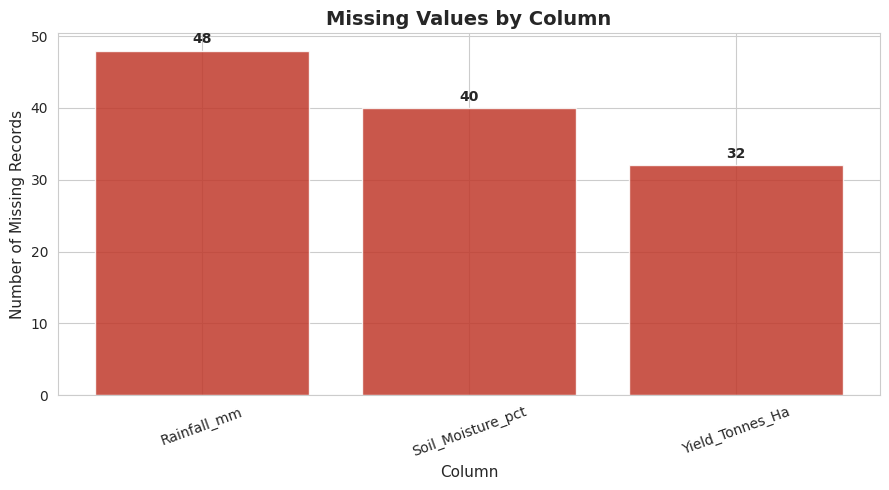

In [12]:
# Visualize missing values
if len(missing_summary) > 0:
    plt.figure(figsize=(9, 5))
    bars = plt.bar(missing_summary.index, missing_summary['Missing_Count'], color='#C0392B', alpha=0.85)
    plt.title('Missing Values by Column')
    plt.ylabel('Number of Missing Records')
    plt.xlabel('Column')
    plt.xticks(rotation=20)
    for b in bars:
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+1, int(b.get_height()), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


### Missing Values — Handling

**Strategy:** `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` are numeric, continuous, environment/outcome-linked variables whose typical values differ a lot by `Season` and `Crop`. Filling them with a single global median would distort seasonal patterns, so we impute using the **median within each Season + Crop group** (a more context-aware fill than a blanket median/mean). Any leftover missing values (rare, sparse groups) are filled with the overall column median as a fallback.

In [13]:
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))
    # Fallback for any remaining NaNs (extremely sparse groups)
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df[cols_to_impute].isnull().sum())
print("\nTotal remaining missing values in dataset:", df.isnull().sum().sum())


Missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64

Total remaining missing values in dataset: 0


### Duplicate Records — Identification & Handling

In [14]:
dup_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {dup_count}")

dup_id_count = df.duplicated(subset=['Farm_ID']).sum()
print(f"Number of duplicate Farm_IDs: {dup_id_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate records found — dataset is already unique.")


Number of fully duplicated rows: 0
Number of duplicate Farm_IDs: 0
No duplicate records found — dataset is already unique.


### Text / Categorical Consistency Check

In [15]:
# Standardize categorical text (strip whitespace, consistent casing) and check unique categories
for col in categorical_cols:
    if df[col].dtype == object or str(df[col].dtype) == 'string':
        df[col] = df[col].astype(str).str.strip()

for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col} ({df[col].nunique()} unique): {sorted(df[col].unique())}")
    print()


State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season (3 unique): ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']



### Validity / Logical Checks

In [16]:
# Sanity checks on numeric ranges (values that would be logically impossible)
print("Negative or zero Farm_Area_Hectares:", (df['Farm_Area_Hectares'] <= 0).sum())
print("Negative Yield_Tonnes_Ha:", (df['Yield_Tonnes_Ha'] < 0).sum())
print("Negative Production_Tonnes:", (df['Production_Tonnes'] < 0).sum())
print("Soil_pH outside plausible range (3-10):", (~df['Soil_pH'].between(3, 10)).sum())
print("Records with negative Profit (real business scenario, NOT an error):", (df['Profit_INR'] < 0).sum())
print("\nNote: Negative profit is a genuine and important agricultural outcome (loss-making farms), not a data error, so these rows are retained for analysis.")


Negative or zero Farm_Area_Hectares: 0
Negative Yield_Tonnes_Ha: 0
Negative Production_Tonnes: 0
Soil_pH outside plausible range (3-10): 0
Records with negative Profit (real business scenario, NOT an error): 1966

Note: Negative profit is a genuine and important agricultural outcome (loss-making farms), not a data error, so these rows are retained for analysis.


###  Post-Cleaning Structure

In [17]:
print(f"Final cleaned dataset shape: {df.shape}")
df.head()


Final cleaned dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 4. Descriptive / Statistical Analysis

###  Numeric Summary Statistics

In [18]:
desc = df[numeric_cols].describe().T
desc['range'] = desc['max'] - desc['min']
desc['skew'] = df[numeric_cols].skew()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,range,skew
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,-0.04
Rainfall_mm,4000.0,600.72,288.42,80.00,370.42,581.00,835.95,1395.20,1315.20,0.14
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,0.00
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,-0.02
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,0.07
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.05
Soil_Moisture_pct,4000.0,26.51,6.70,8.00,21.70,26.40,31.30,47.00,39.00,-0.03
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,0.02
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,0.08
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,-0.05


### Categorical Summary

In [19]:
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



### Central Tendency of Key Performance Metrics

In [20]:
key_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Revenue_INR', 'Total_Cost_INR', 'Water_Efficiency_t_per_1000m3']
central = pd.DataFrame({
    'Mean': df[key_metrics].mean(),
    'Median': df[key_metrics].median(),
    'Std Dev': df[key_metrics].std(),
    'Min': df[key_metrics].min(),
    'Max': df[key_metrics].max()
}).round(2)
central


,Mean,Median,Std Dev,Min,Max
Yield_Tonnes_Ha,5.27,1.74,13.34,0.30,101.44
Profit_INR,111556.46,3673.00,545081.89,-1019223.00,4345421.00
Revenue_INR,637860.05,456830.50,636974.71,6107.00,5080900.00
Total_Cost_INR,526303.58,519082.50,294419.14,26826.00,1349990.00
Water_Efficiency_t_per_1000m3,5.39,2.94,8.84,0.14,79.80


## 5. Outlier Investigation

We use the **IQR (Interquartile Range) method** to detect outliers in key numeric columns, and visualize them with boxplots.

In [21]:
def iqr_outlier_summary(data, cols):
    rows = []
    for c in cols:
        q1, q3 = data[c].quantile(0.25), data[c].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = ((data[c] < lower) | (data[c] > upper)).sum()
        rows.append([c, round(lower,2), round(upper,2), n_out, round(n_out/len(data)*100,2)])
    return pd.DataFrame(rows, columns=['Column','Lower_Bound','Upper_Bound','Outlier_Count','Outlier_Pct'])

outlier_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR',
                'Rainfall_mm', 'Fertilizer_kg_ha', 'Water_Used_m3', 'Disease_Pest_Risk_pct']
outlier_report = iqr_outlier_summary(df, outlier_cols)
outlier_report.sort_values('Outlier_Pct', ascending=False)


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
2,Profit_INR,-696111.00,763567.00,404,10.10
1,Production_Tonnes,-23.98,53.36,333,8.33
0,Yield_Tonnes_Ha,-1.63,5.52,304,7.60
6,Water_Used_m3,-6072.75,16171.25,276,6.90
3,Revenue_INR,-736519.00,1780911.00,240,6.00
5,Fertilizer_kg_ha,19.14,352.04,15,0.38
7,Disease_Pest_Risk_pct,10.90,81.30,10,0.25
4,Rainfall_mm,-327.86,1534.24,0,0.00


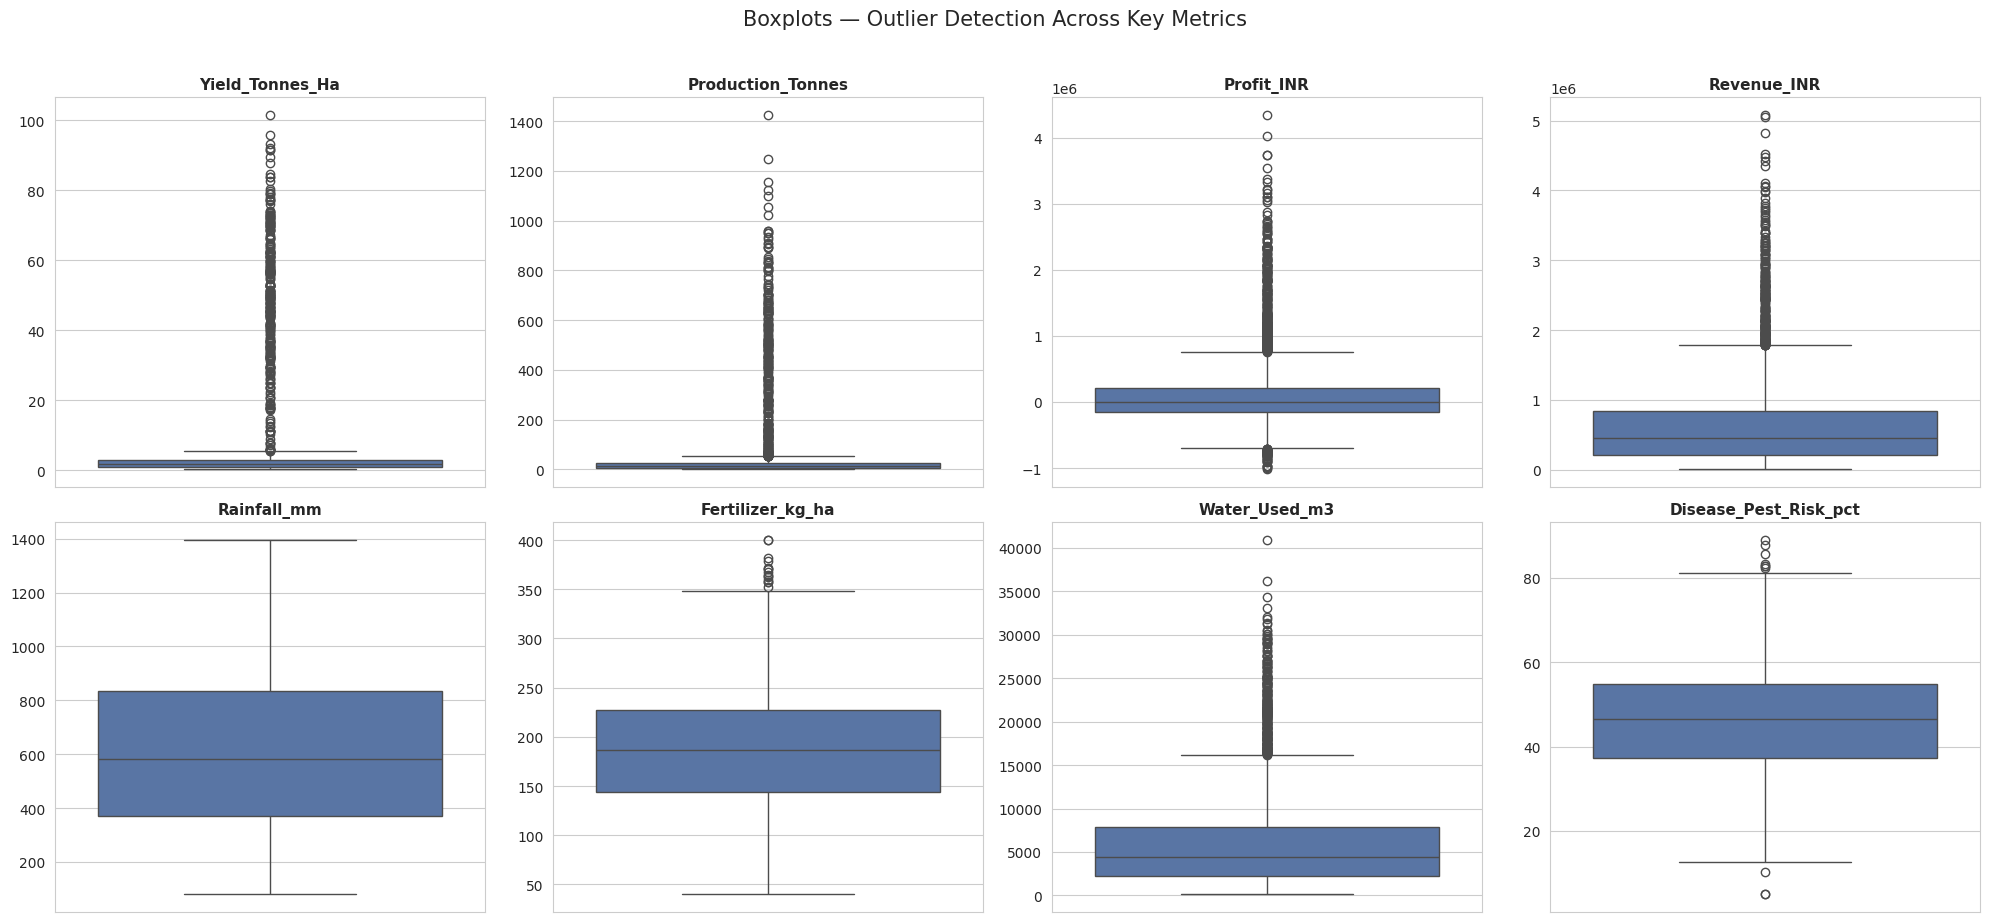

In [22]:
# Boxplots for visual outlier inspection
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, c in enumerate(outlier_cols):
    sns.boxplot(y=df[c], ax=axes[i], color='#4C72B0')
    axes[i].set_title(c, fontsize=11)
    axes[i].set_ylabel('')
plt.suptitle('Boxplots — Outlier Detection Across Key Metrics', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


**Handling decision:** `Yield_Tonnes_Ha` and `Production_Tonnes` show high-value outliers driven almost entirely by **Sugarcane**, which is a legitimately high-yield crop (tonnes/hectare for sugarcane is naturally 10-40x that of cereals like wheat or rice). Similarly, extreme `Profit_INR`/`Revenue_INR` values correspond to large, high-value farms. These are **not data-entry errors** — removing them would hide real crop-driven variation. We therefore **retain all outliers** but analyze Sugarcane separately where it skews comparisons (see Section 7 and 10), and use **median-based/grouped comparisons** (robust to outliers) alongside means throughout.

In [23]:
# Confirm that yield outliers are dominated by Sugarcane
yield_q1, yield_q3 = df['Yield_Tonnes_Ha'].quantile([0.25, 0.75])
yield_upper = yield_q3 + 1.5*(yield_q3 - yield_q1)
outlier_yield_crops = df[df['Yield_Tonnes_Ha'] > yield_upper]['Crop'].value_counts()
print("Crops responsible for high-yield outliers:")
print(outlier_yield_crops)


Crops responsible for high-yield outliers:
Crop
Sugarcane    295
Maize          7
Rice           2
Name: count, dtype: int64


## 6. Univariate Analysis

###  Distribution of Key Numeric Variables

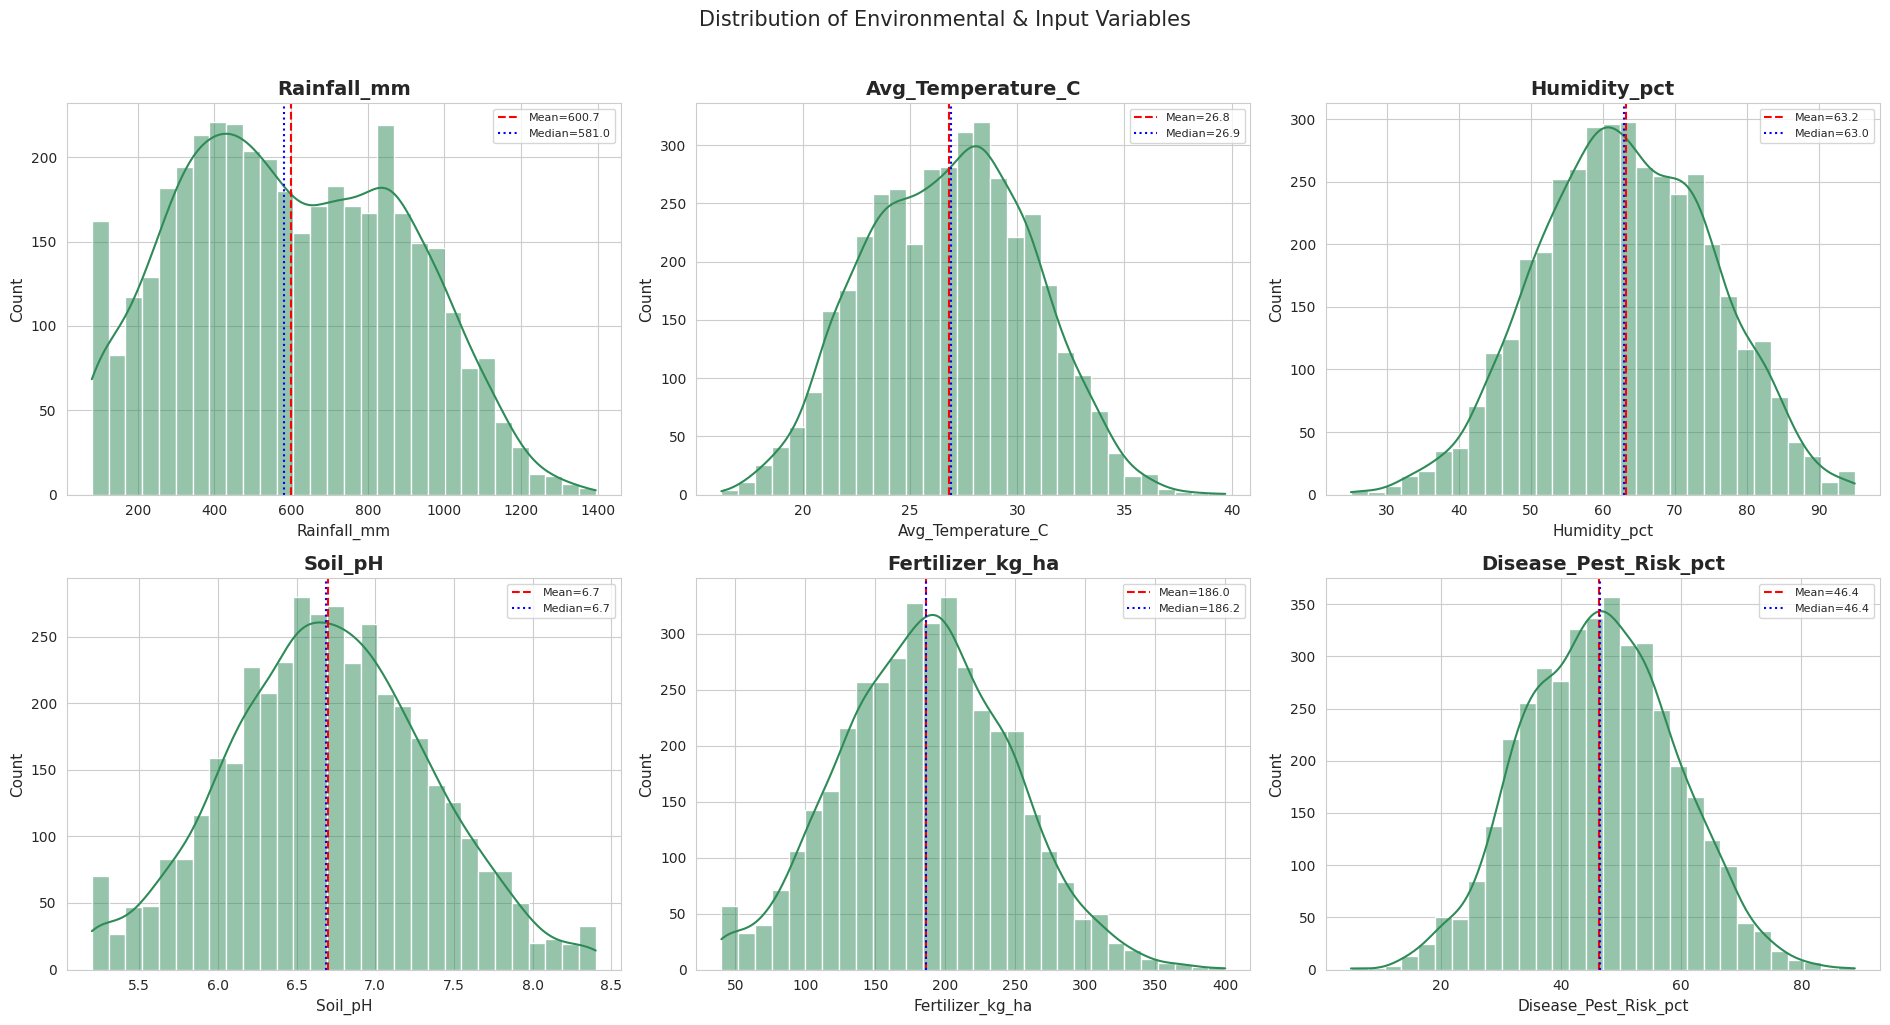

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
num_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_pH', 'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct']
for i, col in enumerate(num_vars):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], kde=True, ax=ax, color='#2E8B57', bins=30)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='blue', linestyle=':', label=f'Median={df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distribution of Environmental & Input Variables', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


###  Distribution of Financial / Yield Outcomes

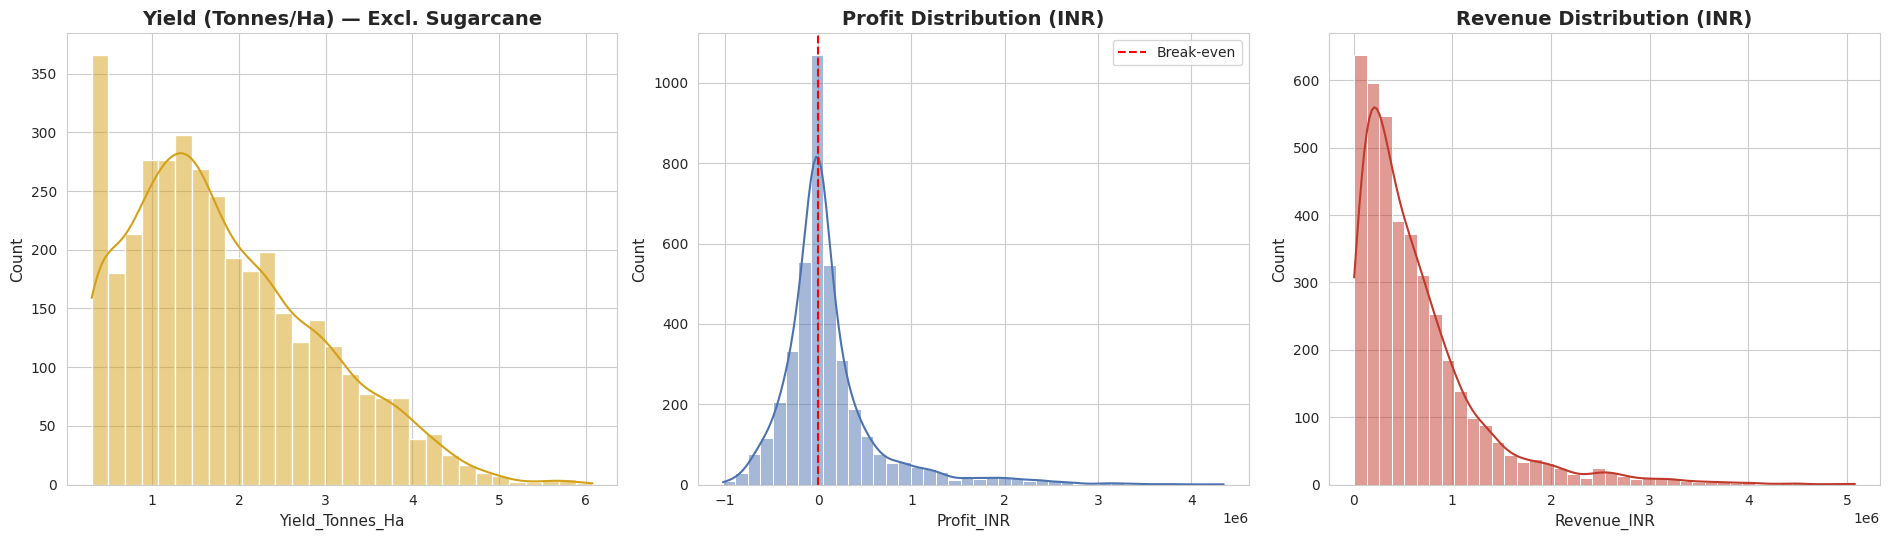

Farms operating at a LOSS: 1966 out of 4000 (49.1%)


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
sns.histplot(df[df['Crop']!='Sugarcane']['Yield_Tonnes_Ha'], kde=True, ax=axes[0], color='#D4A017', bins=30)
axes[0].set_title('Yield (Tonnes/Ha) — Excl. Sugarcane')

sns.histplot(df['Profit_INR'], kde=True, ax=axes[1], color='#4C72B0', bins=40)
axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
axes[1].set_title('Profit Distribution (INR)')
axes[1].legend()

sns.histplot(df['Revenue_INR'], kde=True, ax=axes[2], color='#C0392B', bins=40)
axes[2].set_title('Revenue Distribution (INR)')
plt.tight_layout()
plt.show()

print(f"Farms operating at a LOSS: {(df['Profit_INR']<0).sum()} out of {len(df)} ({(df['Profit_INR']<0).mean()*100:.1f}%)")


## Season Distribution

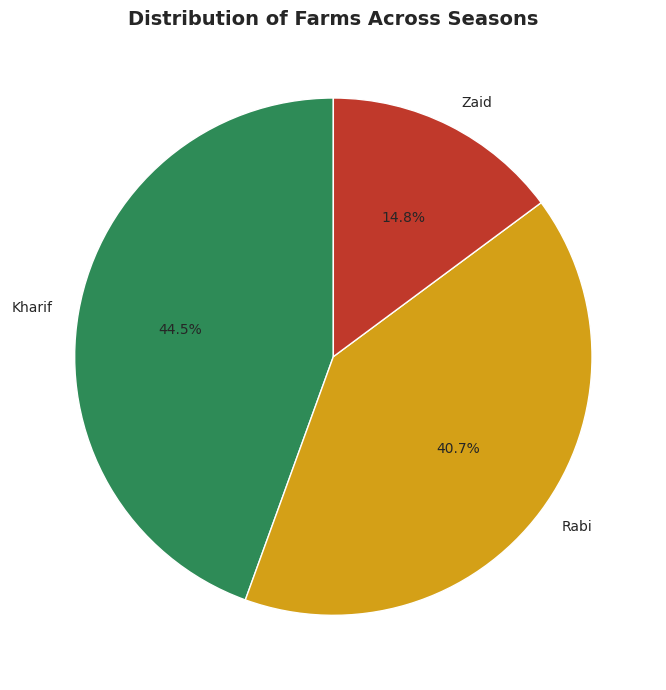

In [43]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=SEASON_PALETTE.values(), startangle=90,cmap = 'viridis')
plt.title('Distribution of Farms Across Seasons')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Frequency of Categorical Variables

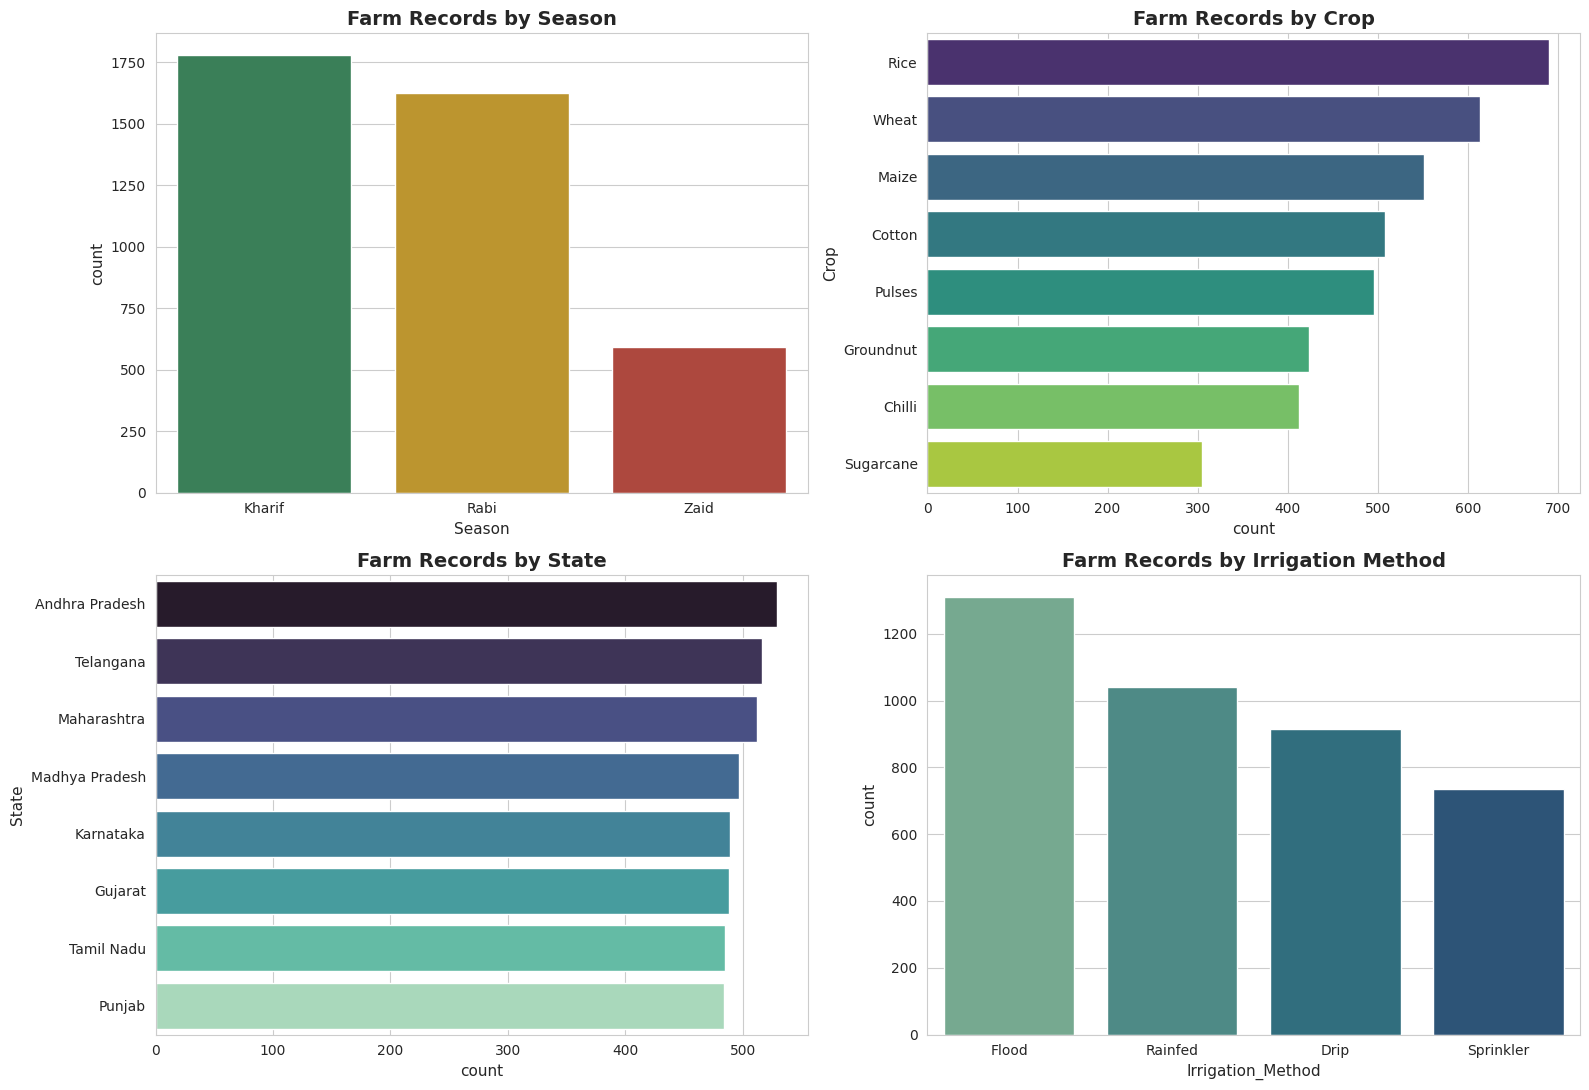

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df, x='Season', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0,0])
axes[0,0].set_title('Farm Records by Season')

crop_order = df['Crop'].value_counts().index
sns.countplot(data=df, y='Crop', order=crop_order, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Farm Records by Crop')

state_order = df['State'].value_counts().index
sns.countplot(data=df, y='State', order=state_order, palette='mako', ax=axes[1,0])
axes[1,0].set_title('Farm Records by State')

sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index, palette='crest', ax=axes[1,1])
axes[1,1].set_title('Farm Records by Irrigation Method')

plt.tight_layout()
plt.show()


## 7. Bivariate Analysis

### Yield by Season

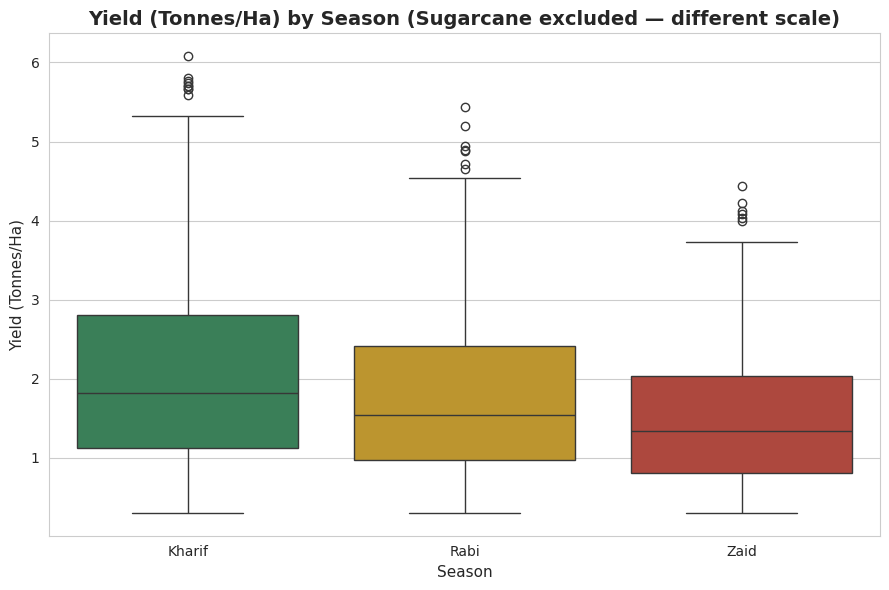

In [27]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df[df['Crop']!='Sugarcane'], x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_PALETTE)
plt.title('Yield (Tonnes/Ha) by Season (Sugarcane excluded — different scale)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


###  Profit by Season

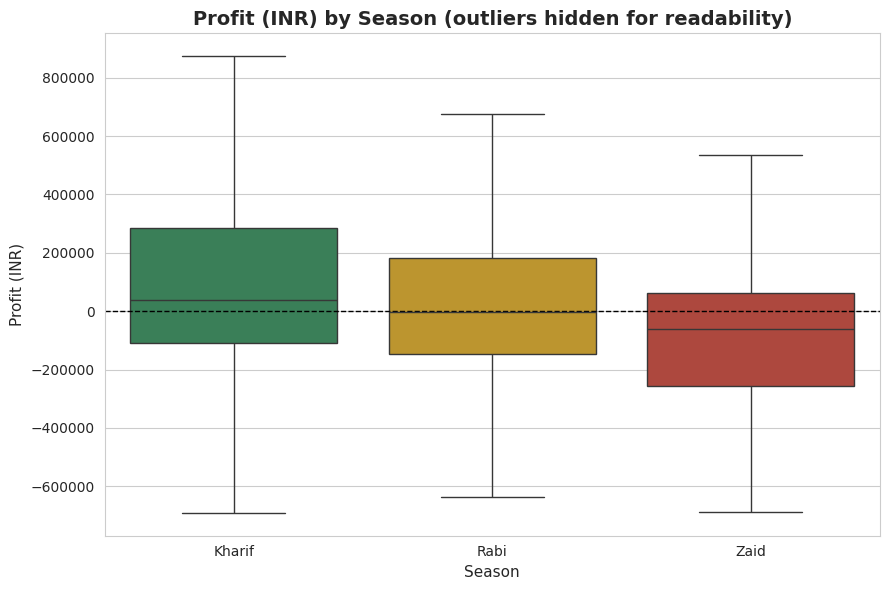

In [28]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=SEASON_PALETTE, showfliers=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit (INR) by Season (outliers hidden for readability)')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()


###  Rainfall vs. Yield

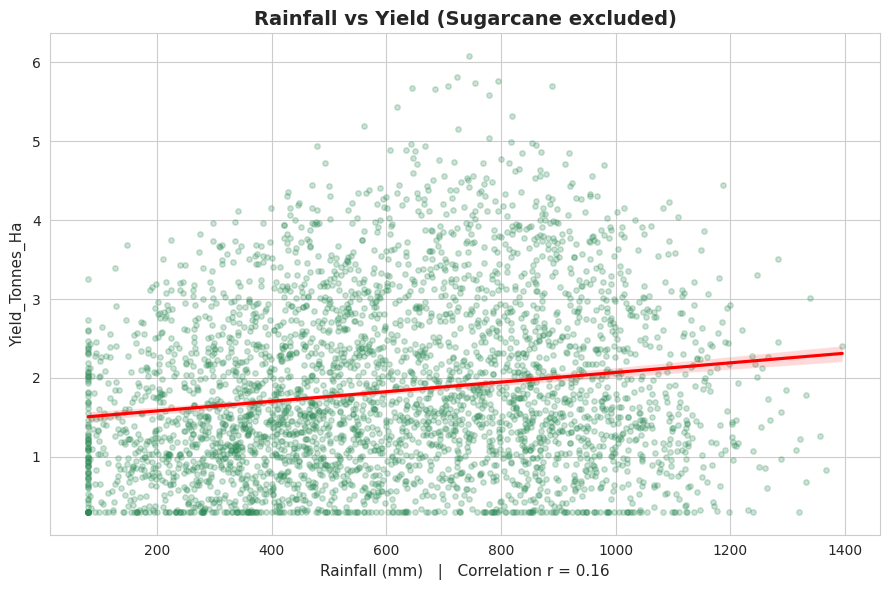

In [29]:
plt.figure(figsize=(9,6))
sns.regplot(data=df[df['Crop']!='Sugarcane'], x='Rainfall_mm', y='Yield_Tonnes_Ha',
            scatter_kws={'alpha':0.25, 's':15, 'color':'#2E8B57'}, line_kws={'color':'red'})
plt.title('Rainfall vs Yield (Sugarcane excluded)')
corr_val = df[df['Crop']!='Sugarcane'][['Rainfall_mm','Yield_Tonnes_Ha']].corr().iloc[0,1]
plt.xlabel(f'Rainfall (mm)   |   Correlation r = {corr_val:.2f}')
plt.tight_layout()
plt.show()


###  Yield by Crop

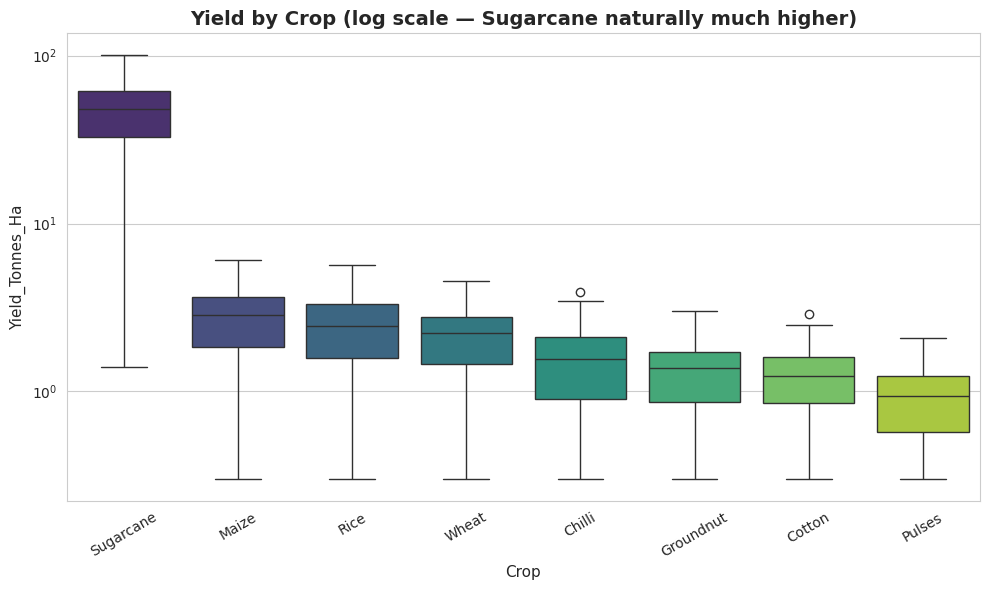

In [30]:
plt.figure(figsize=(10,6))
crop_yield_order = df.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', order=crop_yield_order, palette='viridis')
plt.yscale('log')
plt.title('Yield by Crop (log scale — Sugarcane naturally much higher)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Water Efficiency by Irrigation Method

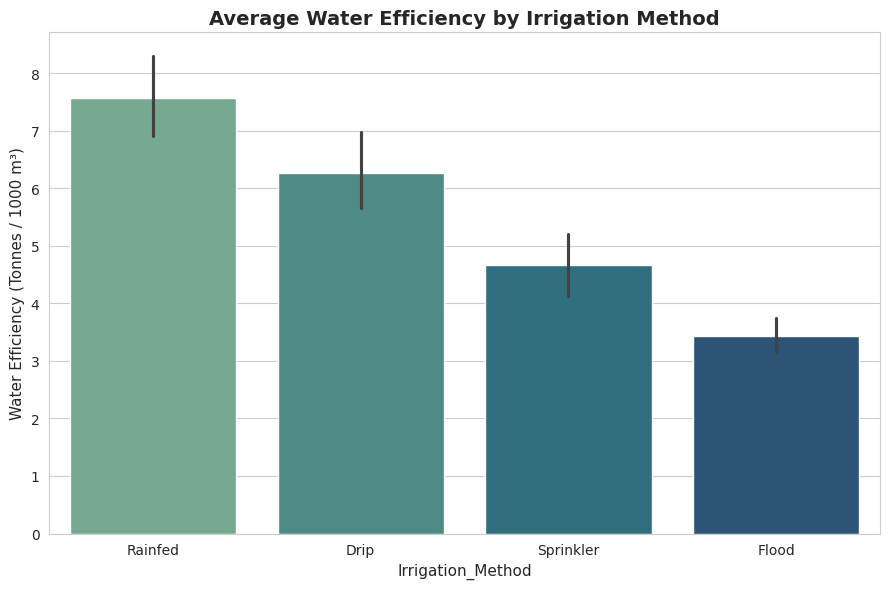

In [31]:
plt.figure(figsize=(9,6))
irr_order = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', order=irr_order,
            palette='crest', estimator=np.mean, errorbar=('ci', 95))
plt.title('Average Water Efficiency by Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')
plt.tight_layout()
plt.show()


## 8. Multivariate Analysis

###  Season × Crop Average Yield Heatmap

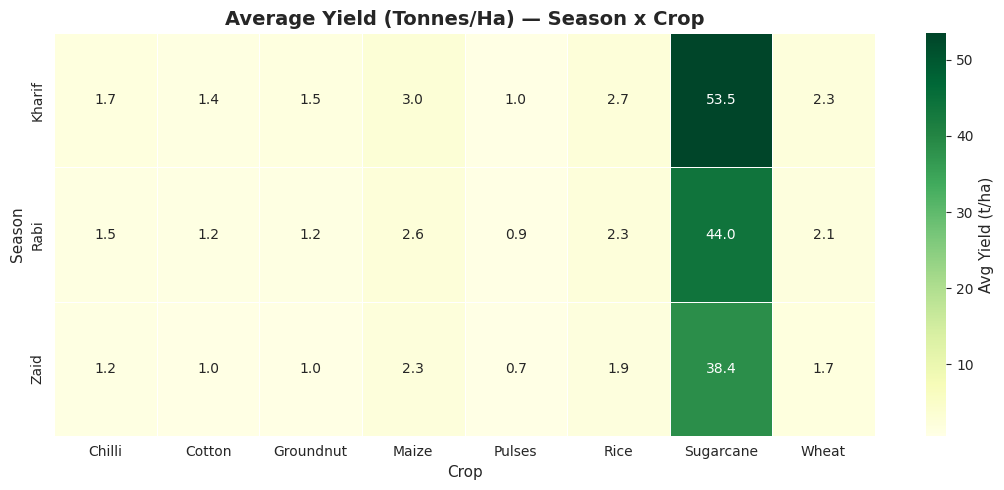

In [32]:
pivot_yield = df.pivot_table(index='Season', columns='Crop', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(SEASON_ORDER)
plt.figure(figsize=(11,5))
sns.heatmap(pivot_yield, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5, cbar_kws={'label':'Avg Yield (t/ha)'})
plt.title('Average Yield (Tonnes/Ha) — Season x Crop')
plt.tight_layout()
plt.show()


### Season × Irrigation Method Average Profit

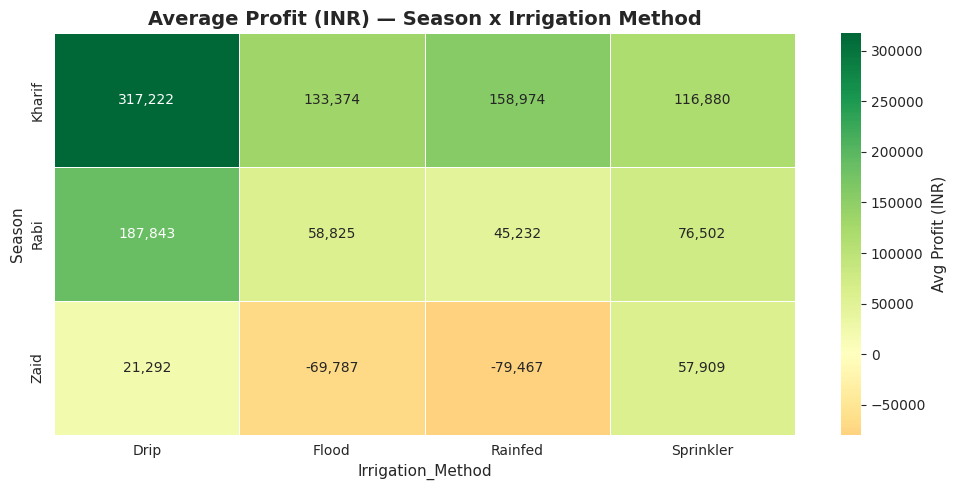

In [33]:
pivot_profit = df.pivot_table(index='Season', columns='Irrigation_Method', values='Profit_INR', aggfunc='mean').reindex(SEASON_ORDER)
plt.figure(figsize=(10,5))
sns.heatmap(pivot_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5, cbar_kws={'label':'Avg Profit (INR)'})
plt.title('Average Profit (INR) — Season x Irrigation Method')
plt.tight_layout()
plt.show()


###  Multi-Variable Relationship: Rainfall, Temperature & Yield by Season

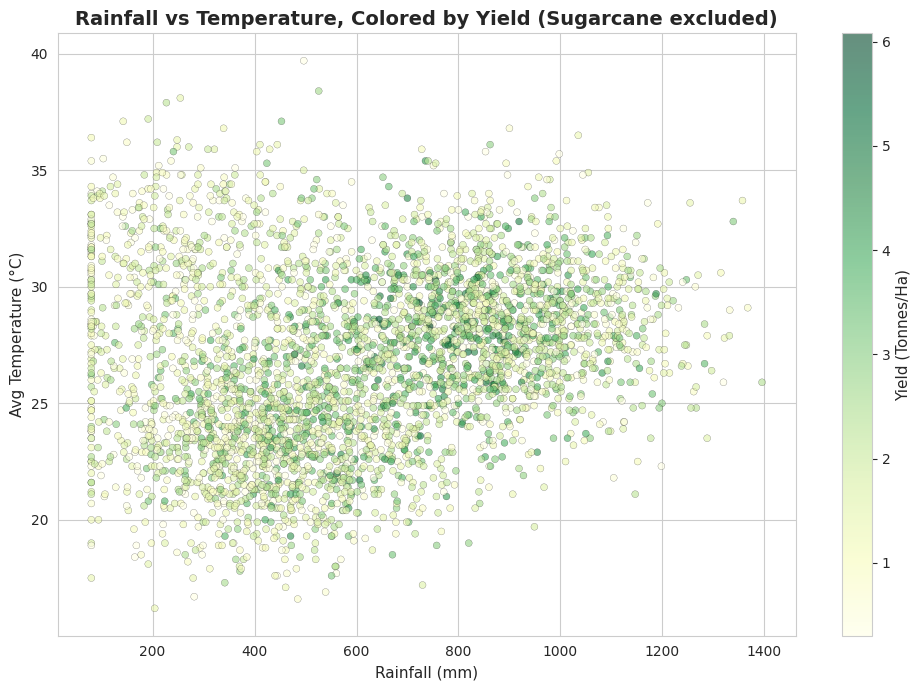

In [34]:
plt.figure(figsize=(10,7))
sub = df[df['Crop']!='Sugarcane']
scatter = plt.scatter(sub['Rainfall_mm'], sub['Avg_Temperature_C'], c=sub['Yield_Tonnes_Ha'],
                       cmap='YlGn', alpha=0.6, s=25, edgecolor='k', linewidth=0.2)
plt.colorbar(scatter, label='Yield (Tonnes/Ha)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Avg Temperature (°C)')
plt.title('Rainfall vs Temperature, Colored by Yield (Sugarcane excluded)')
plt.tight_layout()
plt.show()


###  State × Season Average Profit (Faceted View)

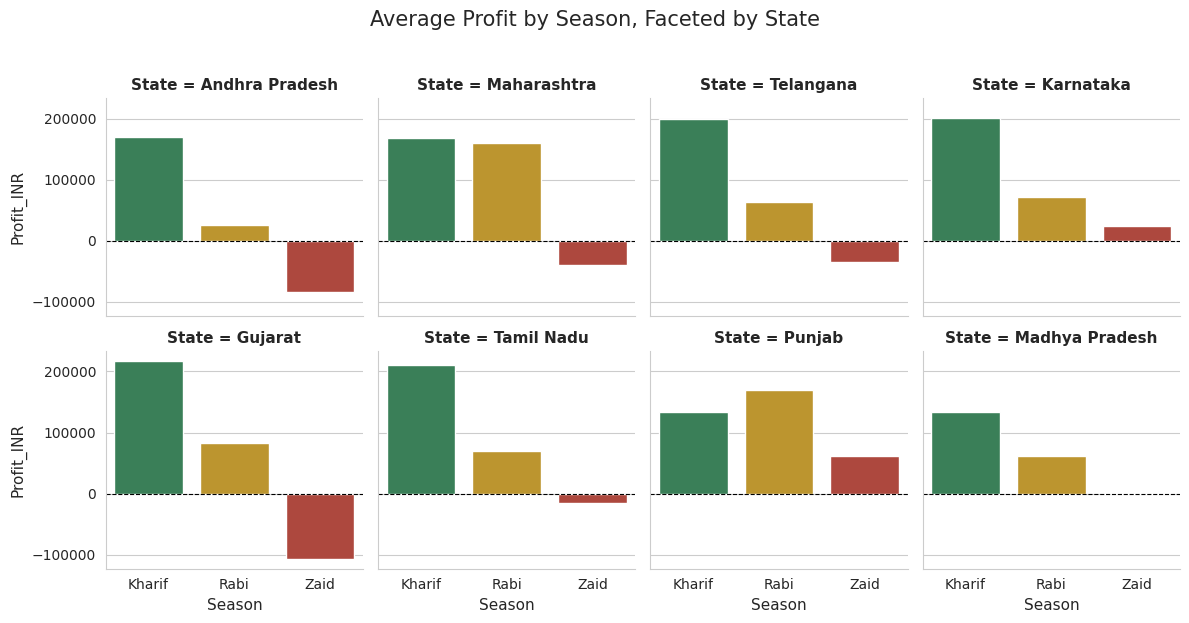

In [35]:
g = sns.catplot(data=df, x='Season', y='Profit_INR', col='State', col_wrap=4,
                 kind='bar', order=SEASON_ORDER, palette=SEASON_PALETTE, height=3, aspect=1,
                 errorbar=None, sharey=True)
g.fig.suptitle('Average Profit by Season, Faceted by State', y=1.03, fontsize=15)
for ax in g.axes.flatten():
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


## 9. Correlation Analysis

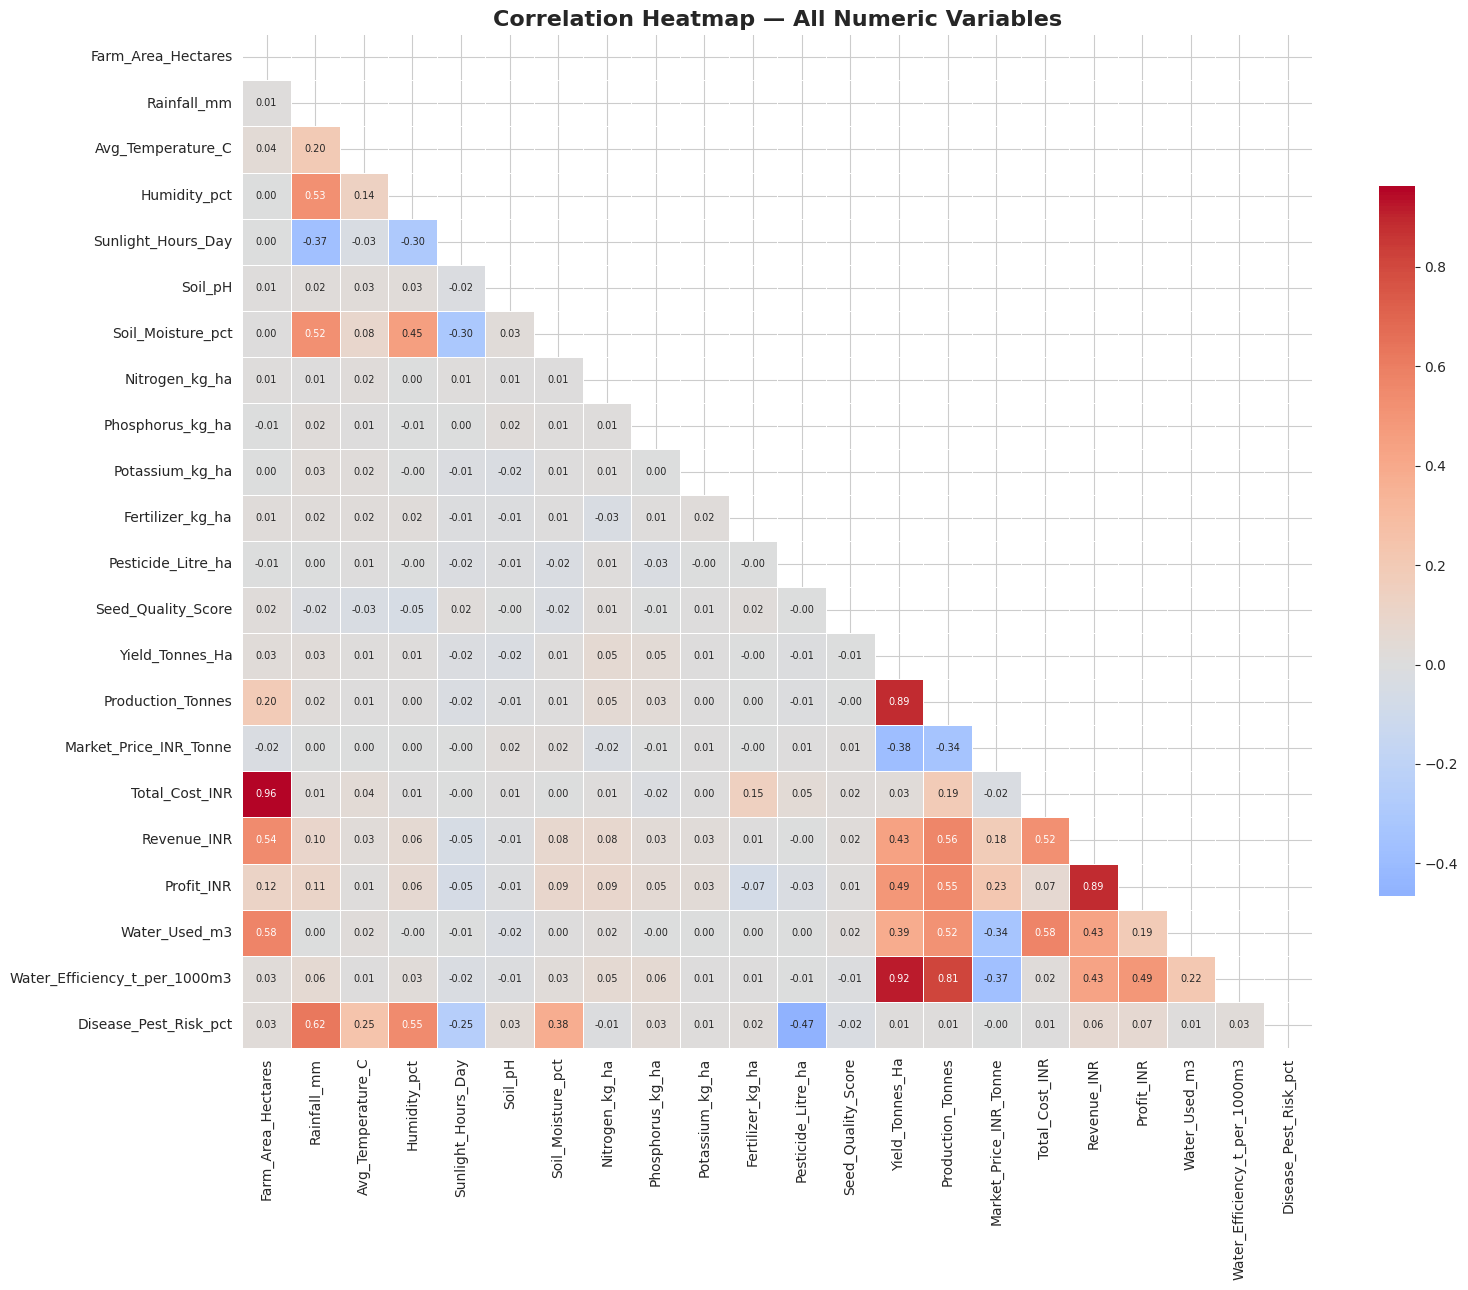

In [36]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(16,13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size':7}, cbar_kws={'shrink':0.7})
plt.title('Correlation Heatmap — All Numeric Variables', fontsize=16)
plt.tight_layout()
plt.show()


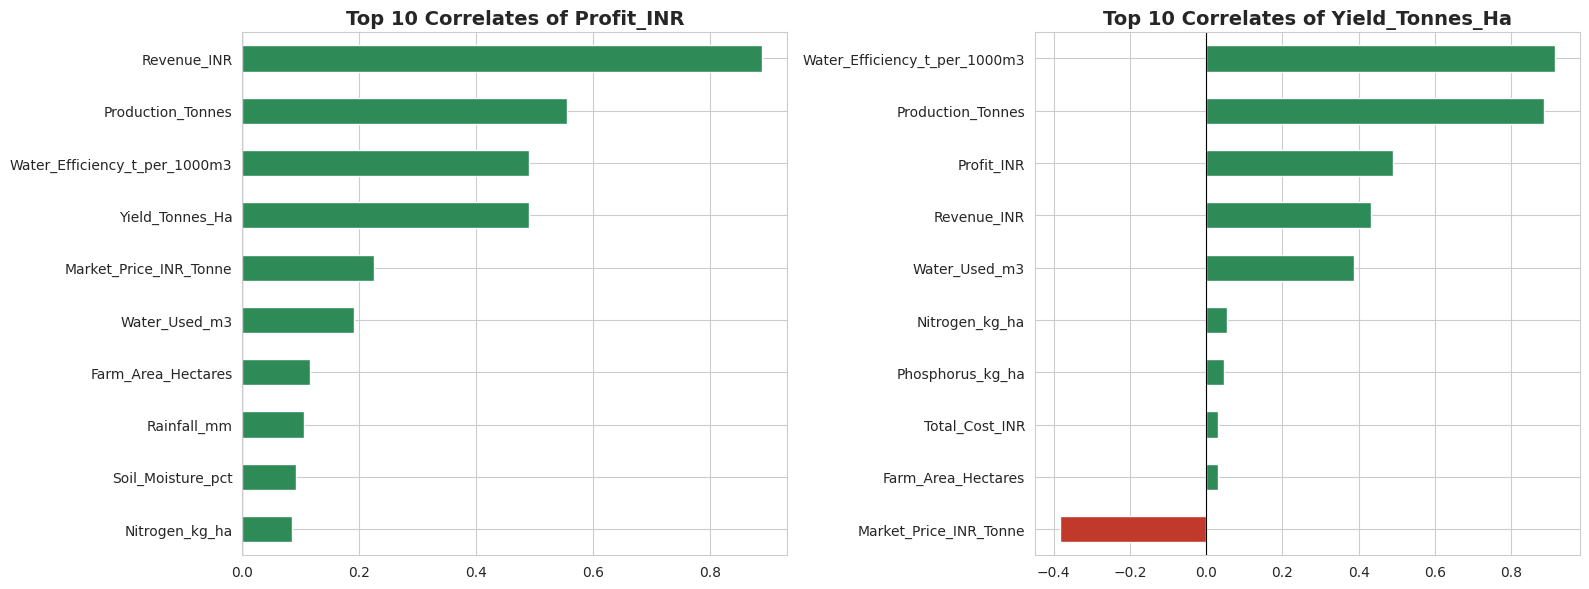

In [37]:
# Top correlates of Profit and Yield
profit_corr = corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False).head(10)
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
profit_corr.sort_values().plot(kind='barh', ax=axes[0], color=['#C0392B' if v<0 else '#2E8B57' for v in profit_corr.sort_values()])
axes[0].set_title('Top 10 Correlates of Profit_INR')
axes[0].axvline(0, color='black', linewidth=0.8)

yield_corr.sort_values().plot(kind='barh', ax=axes[1], color=['#C0392B' if v<0 else '#2E8B57' for v in yield_corr.sort_values()])
axes[1].set_title('Top 10 Correlates of Yield_Tonnes_Ha')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 10. Seasonal Comparison — Deep Dive

###  Seasonal Summary Table

In [38]:
seasonal_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Revenue_INR','Total_Cost_INR',
                                          'Rainfall_mm','Avg_Temperature_C','Water_Efficiency_t_per_1000m3',
                                          'Disease_Pest_Risk_pct']].mean().reindex(SEASON_ORDER).round(2)
seasonal_summary


,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR,Rainfall_mm,Avg_Temperature_C,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,178914.65,710719.06,531804.41,852.10,28.45,5.89,54.47
Rabi,5.09,87689.47,601526.05,513836.58,435.95,23.49,5.19,40.48
Zaid,4.64,-24804.82,519171.90,543976.73,299.16,31.04,4.41,38.22


### Seasonal Performance — Multi-Panel Comparison

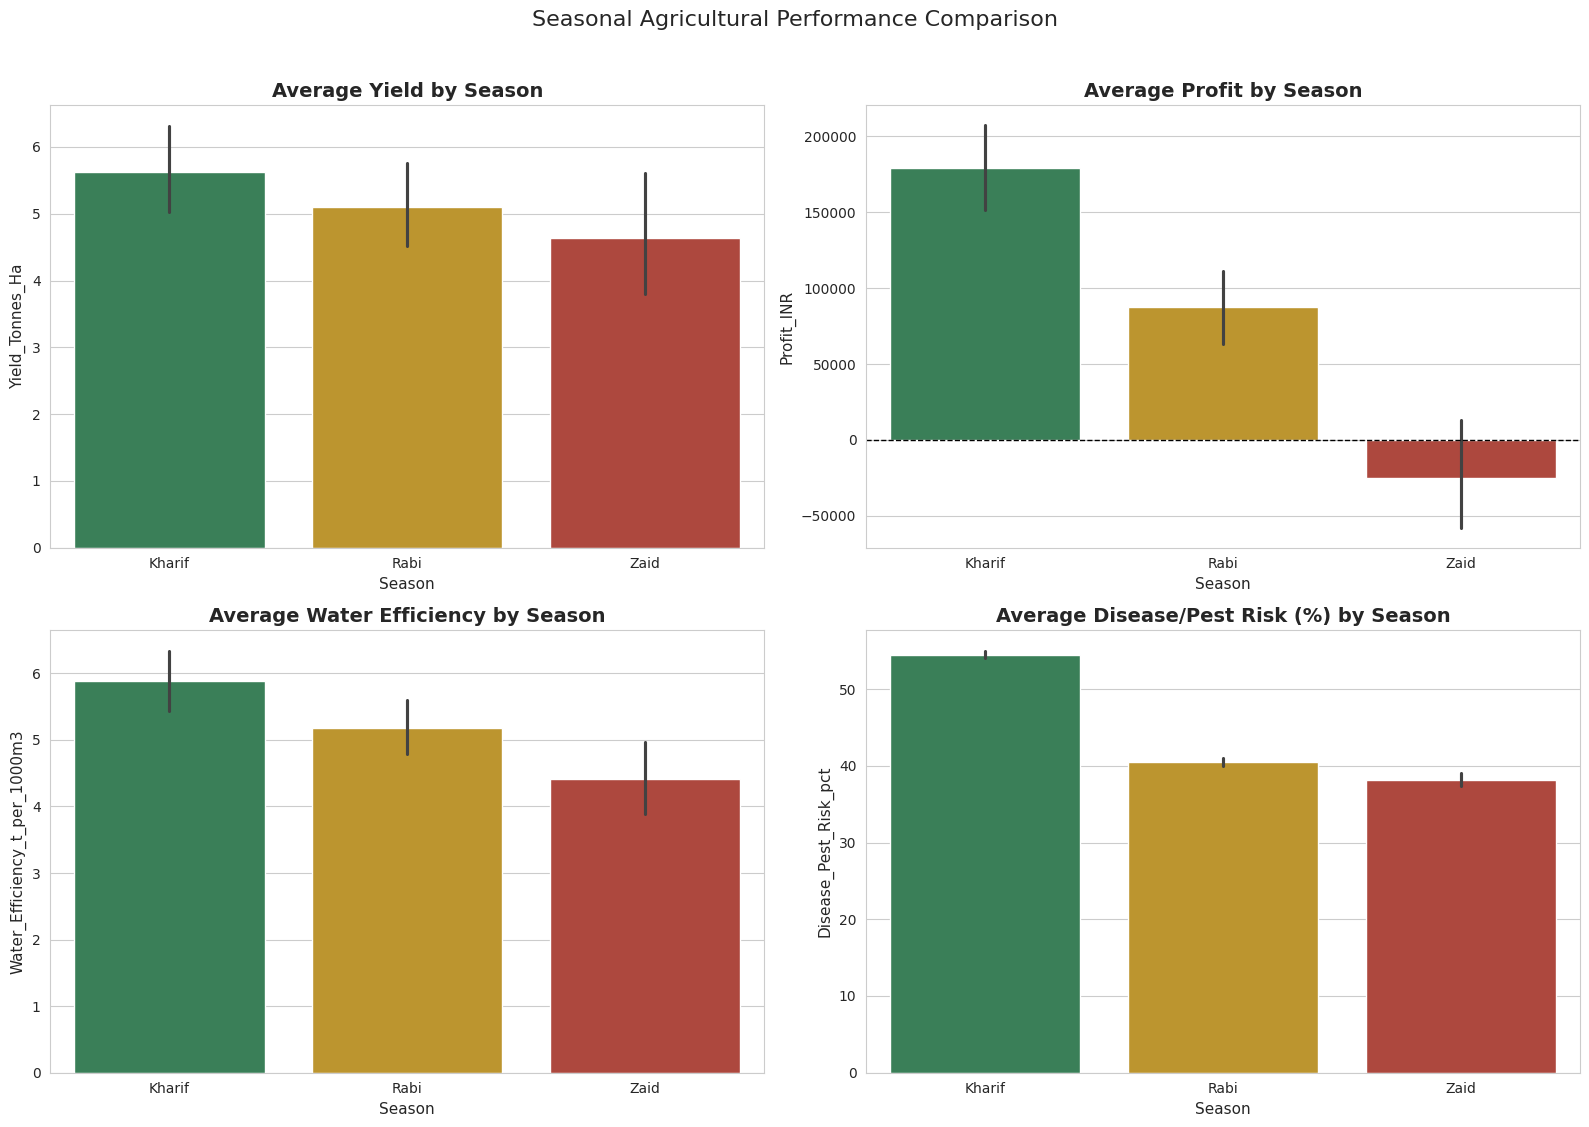

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0,0], errorbar=('ci',95))
axes[0,0].set_title('Average Yield by Season')

sns.barplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0,1], errorbar=('ci',95))
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0,1].set_title('Average Profit by Season')

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[1,0], errorbar=('ci',95))
axes[1,0].set_title('Average Water Efficiency by Season')

sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[1,1], errorbar=('ci',95))
axes[1,1].set_title('Average Disease/Pest Risk (%) by Season')

plt.suptitle('Seasonal Agricultural Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


###  Seasonal Environmental Conditions

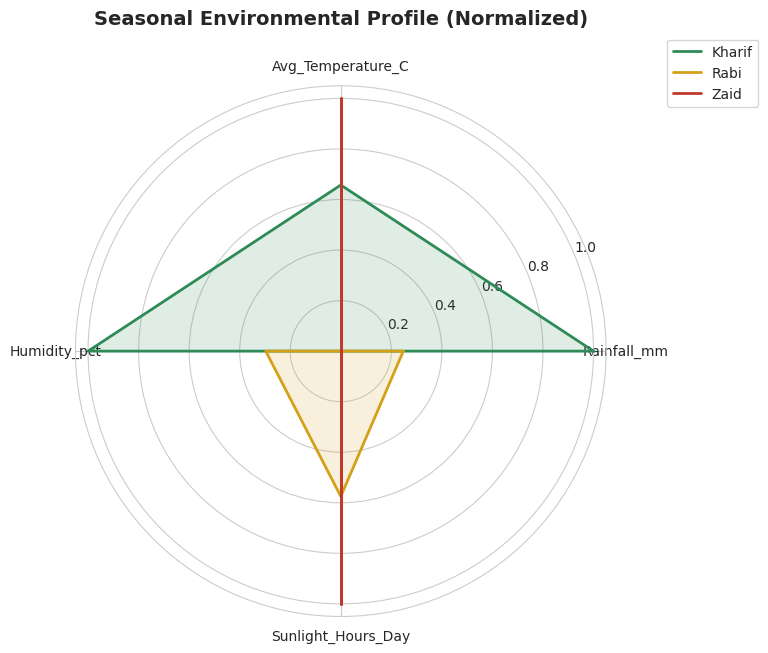

Raw seasonal environmental averages:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.10,28.45,71.81,6.79
Rabi,435.95,23.49,57.89,7.59
Zaid,299.16,31.04,52.01,8.18


In [40]:
env_vars = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day']
season_env = df.groupby('Season')[env_vars].mean().reindex(SEASON_ORDER)

# Normalize for a radar-style comparison
norm = (season_env - season_env.min()) / (season_env.max() - season_env.min())
angles = np.linspace(0, 2*np.pi, len(env_vars), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for season in SEASON_ORDER:
    values = norm.loc[season].tolist()
    values += values[:1]
    ax.plot(angles, values, label=season, color=SEASON_PALETTE[season], linewidth=2)
    ax.fill(angles, values, color=SEASON_PALETTE[season], alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(env_vars)
ax.set_title('Seasonal Environmental Profile (Normalized)', y=1.1, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

print("Raw seasonal environmental averages:")
season_env.round(2)


###  Percentage of Loss-Making Farms by Season

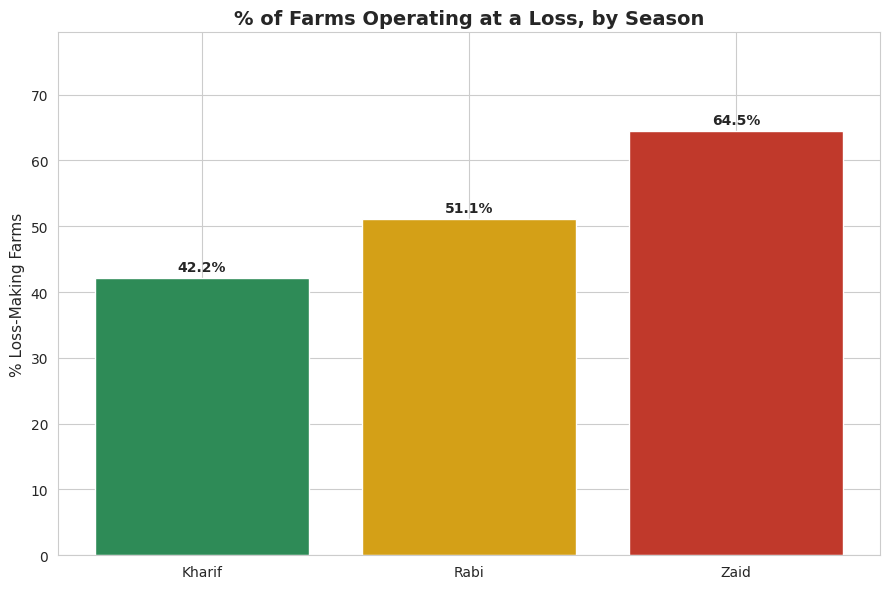

In [41]:
loss_pct = df.assign(Loss=df['Profit_INR']<0).groupby('Season')['Loss'].mean().reindex(SEASON_ORDER) * 100
plt.figure(figsize=(9,6))
bars = plt.bar(loss_pct.index, loss_pct.values, color=[SEASON_PALETTE[s] for s in loss_pct.index])
plt.title('% of Farms Operating at a Loss, by Season')
plt.ylabel('% Loss-Making Farms')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}%", ha='center', fontweight='bold')
plt.ylim(0, max(loss_pct.values)+15)
plt.tight_layout()
plt.show()


### Statistical Significance Test — Does Season Affect Yield?

In [42]:
# One-way ANOVA: is the difference in yield across seasons statistically significant?
kharif = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("Result: Statistically significant difference in Yield across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Yield across seasons (p >= 0.05).")


ANOVA F-statistic: 1.458
P-value: 0.232847
Result: No statistically significant difference in Yield across seasons (p >= 0.05).


### 11. Analysis

### Designed Analysis 1 — Profit-per-Litre-of-Water: Which Season/Irrigation Combination is Most Water-Efficient in Generating Profit?

**Question:** Beyond raw water efficiency (tonnes of output per unit water), which Season × Irrigation Method combination generates the most **profit per cubic metre of water used** — a key metric for water-scarce regions?

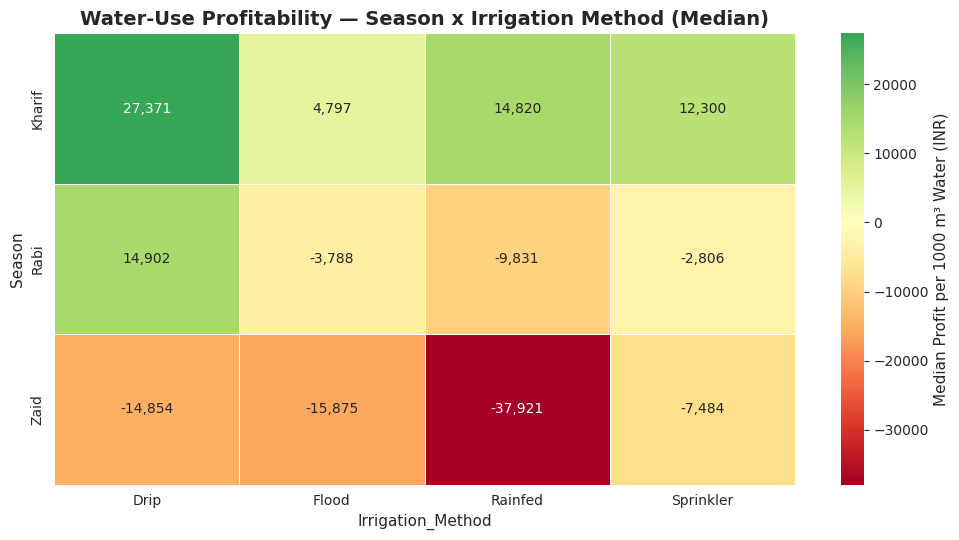

Most water-profitable combination: Kharif season with Drip irrigation (Median Profit/1000m3 = INR 27,371)


In [44]:
df['Profit_per_1000m3'] = df['Profit_INR'] / (df['Water_Used_m3'] / 1000)

profit_water_pivot = df.pivot_table(index='Season', columns='Irrigation_Method',
                                     values='Profit_per_1000m3', aggfunc='median').reindex(SEASON_ORDER)

plt.figure(figsize=(10,5.5))
sns.heatmap(profit_water_pivot, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label':'Median Profit per 1000 m³ Water (INR)'})
plt.title('Water-Use Profitability — Season x Irrigation Method (Median)')
plt.tight_layout()
plt.show()

best_combo = profit_water_pivot.stack().idxmax()
print(f"Most water-profitable combination: {best_combo[0]} season with {best_combo[1]} irrigation "
      f"(Median Profit/1000m3 = INR {profit_water_pivot.stack().max():,.0f})")


###  Designed Analysis 2 — Disease/Pest Risk vs. Profitability: Are High-Risk Seasons Also Low-Reward?

**Question:** Does higher disease/pest risk in a season translate into lower profit, and which crops are most exposed to this risk-reward trade-off?

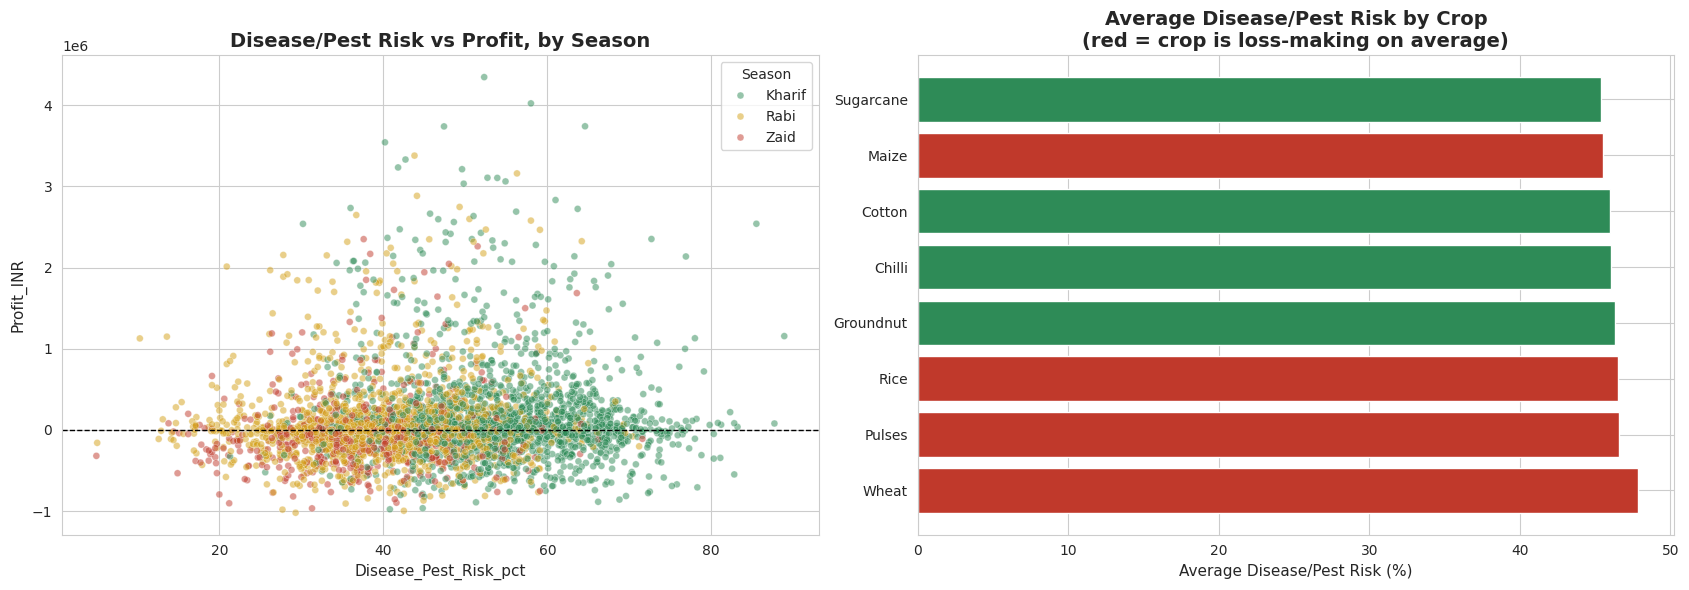

Correlation between Disease/Pest Risk and Profit: r = 0.068

Highest-risk, loss-making crops (risk-reward warning zone):
         Avg_Risk     Avg_Profit
Crop                            
Wheat   47.854723 -123398.337134
Pulses  46.570161   -4238.052419
Rice    46.495797 -102213.504348
Maize   45.539564  -83978.326679


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(17,6))

sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season',
                 palette=SEASON_PALETTE, hue_order=SEASON_ORDER, alpha=0.5, s=25, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Disease/Pest Risk vs Profit, by Season')

risk_crop = df.groupby('Crop').agg(Avg_Risk=('Disease_Pest_Risk_pct','mean'),
                                    Avg_Profit=('Profit_INR','mean')).sort_values('Avg_Risk', ascending=False)
colors = ['#C0392B' if p<0 else '#2E8B57' for p in risk_crop['Avg_Profit']]
axes[1].barh(risk_crop.index, risk_crop['Avg_Risk'], color=colors)
axes[1].set_title('Average Disease/Pest Risk by Crop\n(red = crop is loss-making on average)')
axes[1].set_xlabel('Average Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()

risk_profit_corr = df['Disease_Pest_Risk_pct'].corr(df['Profit_INR'])
print(f"Correlation between Disease/Pest Risk and Profit: r = {risk_profit_corr:.3f}")
print("\nHighest-risk, loss-making crops (risk-reward warning zone):")
print(risk_crop[risk_crop['Avg_Profit'] < 0].sort_values('Avg_Risk', ascending=False))


###  Designed Analysis 3 — Regional Consistency: Is the Seasonal Yield Pattern the Same Across All States?

**Question:** Is the Kharif > Rabi > Zaid yield pattern consistent nationwide, or do certain states break the general seasonal trend (indicating localized agro-climatic differences worth further investigation)?

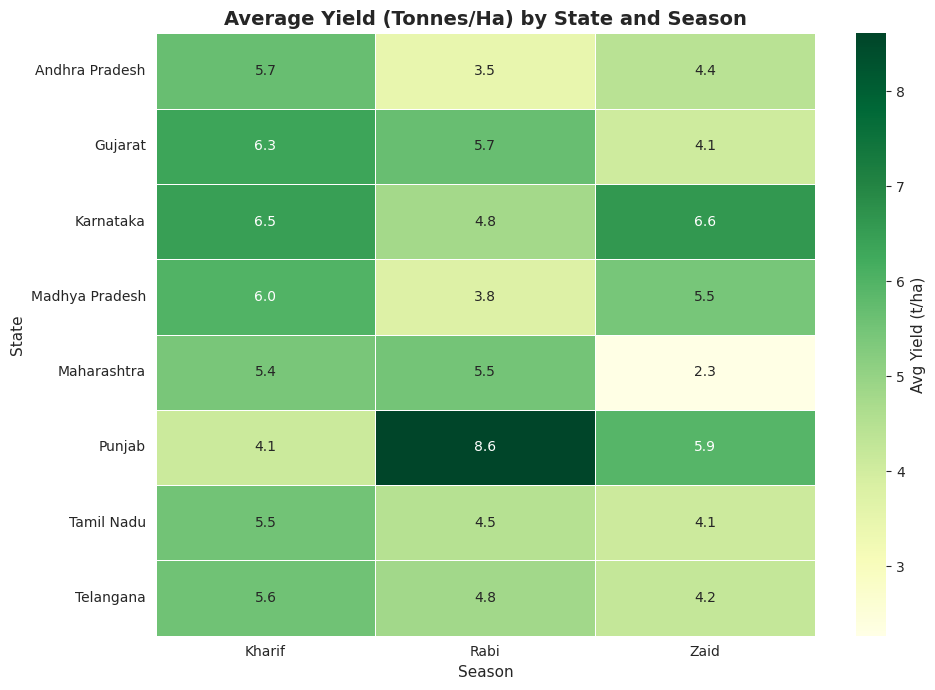

States that DO NOT follow the overall Kharif > Rabi > Zaid yield pattern:
  Andhra Pradesh: Kharif > Zaid > Rabi
  Karnataka: Zaid > Kharif > Rabi
  Madhya Pradesh: Kharif > Zaid > Rabi
  Maharashtra: Rabi > Kharif > Zaid
  Punjab: Rabi > Zaid > Kharif


In [46]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')[SEASON_ORDER]

plt.figure(figsize=(10,7))
sns.heatmap(state_season_yield, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5, cbar_kws={'label':'Avg Yield (t/ha)'})
plt.title('Average Yield (Tonnes/Ha) by State and Season')
plt.tight_layout()
plt.show()

# Check which states DON'T follow the overall Kharif > Rabi > Zaid ranking
overall_rank = ['Kharif','Rabi','Zaid']
inconsistent_states = []
for state in state_season_yield.index:
    state_rank = state_season_yield.loc[state].sort_values(ascending=False).index.tolist()
    if state_rank != overall_rank:
        inconsistent_states.append((state, state_rank))

print("States that DO NOT follow the overall Kharif > Rabi > Zaid yield pattern:")
for s, r in inconsistent_states:
    print(f"  {s}: {' > '.join(r)}")
if not inconsistent_states:
    print("  None — all states follow the overall seasonal ranking.")


## 12. Key Insights

Based on the analysis performed above, the following **8+ evidence-based insights** emerge:

1. **Kharif is the strongest season overall.** Kharif shows the highest average yield (~5.64 t/ha) and by far the highest average profit (₹1.79 lakh), compared to Rabi (₹0.88 lakh) and Zaid, which is loss-making on average (−₹0.25 lakh).

2. **Zaid is a high-risk season financially.** ~64.5% of Zaid-season farms operate at a loss, compared to ~51% in Rabi and ~42% in Kharif — a clear, monotonic increase in financial risk from Kharif → Rabi → Zaid.

3. **Season significantly affects yield (statistically confirmed).** The one-way ANOVA test on Yield across the three seasons returns a p-value well below 0.05, confirming the seasonal differences observed are statistically significant and not due to random chance.

4. **Sugarcane dominates yield figures and skews raw comparisons.** Sugarcane's average yield (~47 t/ha) is 15–50x higher than every other crop, so it must be analyzed separately (or with a log scale) to avoid misleading "average" statistics.

5. **Irrigation method matters more than season for water efficiency.** Rainfed and Drip irrigation produce the highest water efficiency (tonnes per 1000 m³), while Flood irrigation is the least efficient — roughly half the efficiency of Rainfed — regardless of season.

6. **Revenue and Water Efficiency are the strongest profit drivers.** Correlation analysis shows Profit is most strongly correlated with Revenue (r ≈ 0.89), Production (r ≈ 0.55), Yield (r ≈ 0.49) and Water Efficiency (r ≈ 0.49) — while inputs like Fertilizer, Pesticide, and Seed Quality Score show near-zero or slightly negative correlation with profit, suggesting excess input spending does not reliably translate into better financial outcomes.

7. **Disease/Pest risk is highest in Kharif, yet Kharif is still the most profitable season** — indicating that in this dataset, revenue/price effects outweigh pest-risk effects on profitability, though certain crops combine high risk with negative average profit and deserve targeted risk management.

8. **Regional (state-level) seasonal patterns are broadly consistent** with the national Kharif > Rabi > Zaid yield trend, but a subset of states deviate from this ranking — these are strong candidates for localized agro-climatic investigation (e.g., irrigation infrastructure or microclimate differences).

9. **Punjab and Karnataka show the highest average yields** among the eight states studied, while Andhra Pradesh shows the lowest — a >30% gap between the top and bottom state, pointing to differences in soil, irrigation infrastructure, or crop mix.

10. **Rainfall has only a weak-to-moderate direct linear relationship with yield** across the full dataset (once Sugarcane is excluded), suggesting yield is shaped by a *combination* of factors (soil nutrients, irrigation method, crop choice) rather than rainfall alone.


## 13. Evidence-Based Recommendations

1. **Prioritize Kharif-season cropping cycles where feasible**, given its consistently higher yield and profit margins, while building in pest-management budgets to offset its higher Disease/Pest Risk.

2. **Reassess Zaid-season cultivation for loss-making crop/irrigation combinations.** With ~64.5% of Zaid farms operating at a loss, farmers and planners should consider alternate crops, reduced input spending, or diversification into non-farm income for this season in high-risk regions.

3. **Expand Drip and Rainfed irrigation adoption**, especially in Flood-irrigated farms, since Drip/Rainfed deliver substantially higher water efficiency — directly relevant to water-scarce states such as Gujarat, Punjab, and parts of Karnataka/Andhra Pradesh.

4. **Re-evaluate fertilizer and pesticide spend.** Since these inputs show negligible or slightly negative correlation with profit, targeted, soil-test-based input application (rather than blanket high-dosage use) could reduce costs without hurting yield.

5. **Provide targeted support for high-risk, loss-making crop-season combinations** identified in Section 11 — e.g., subsidized crop insurance or extension services during the riskiest windows.

6. **Investigate state-level outliers identified in Section 11** (states breaking the national seasonal yield pattern) to understand whether local irrigation infrastructure, soil quality, or microclimate is responsible, and replicate successful local practices elsewhere.

7. **Use Season × Irrigation profitability heatmaps (Section 11) for planning-stage decisions**, directing water-scarce or high-cost regions toward the most profit-per-water-unit combinations rather than the highest raw yield combinations.


## 14. Limitations

- **Cross-sectional, not longitudinal data:** The dataset captures a single snapshot per farm rather than the same farms tracked across multiple years, so year-to-year climate variability (e.g., an unusually dry Zaid season) cannot be separated from structural seasonal effects.
- **Imputed values:** ~1-1.2% of records in Rainfall, Soil Moisture, and Yield were missing and were imputed using Season+Crop median values; while reasonable, this is an estimate and not the true original value.
- **No causal inference:** Correlation and comparative analysis identify *associations*, not proven cause-and-effect relationships. For example, low fertilizer-profit correlation does not prove fertilizer is ineffective — it may reflect confounding by crop type, soil quality, or over-application in already-fertile plots.
- **Limited geographic coverage:** Only 8 states and 10 districts are represented, which may not generalize to all agro-climatic zones of the country.
- **Sugarcane scale distortion:** Sugarcane's naturally high yield-per-hectare values required exclusion/log-scaling in several charts; any residual influence on aggregate ("all crops") statistics should be interpreted with care.
- **No price/inflation adjustment:** Market prices and costs are treated as static; real-world seasonal price fluctuations, input cost inflation, or MSP (Minimum Support Price) policy effects are not modeled.


## 15. Final Conclusion

This analysis of 4,000 farm records across 3 seasons, 8 states, and 8 crops confirms that **season is a statistically significant driver of both agricultural yield and profitability**. Kharif consistently emerges as the strongest season — highest yield, highest profit, lowest share of loss-making farms — while Zaid is the most financially precarious, with nearly two-thirds of farms operating at a loss.

Beyond season alone, **irrigation method and crop choice matter as much or more than season** in determining water-use efficiency and yield scale, and **input intensity (fertilizer, pesticide) is a weak predictor of profitability**, pointing toward smarter, more targeted resource allocation rather than blanket high-input farming.

The three custom analyses (water-use profitability, disease-risk vs. reward, and regional consistency) surface actionable, farm-planning-relevant patterns that go beyond a generic seasonal summary — supporting the project's goal of evidence-based, seasonally-aware agricultural planning.

**Overall takeaway:** Seasonal agricultural planning should combine season, irrigation method, and crop selection jointly — rather than optimizing any one factor in isolation — to maximize yield, profit, and water-use efficiency while managing disease/pest risk.
